{
    'topic': '猫咪',
    'poem': 
'毛茸茸的身躯，柔软又轻盈，\n踏着无声的步履，穿梭于光影。\n琥珀色的双眸，闪烁着神秘，\n世界在牠眼中，藏着小秘密。\n
\n慵懒地卧在阳光下，打着小盹，\n梦里是否追逐，那摇曳的彩绳？\n忽而又跃起，身手何等敏捷，\n利爪收于掌中，玩弄着一切
。\n\n轻柔的咕噜声，在喉间低回，\n是满足的乐章，是无言的依偎。\n偶尔一声“喵”，软软地呼唤，\n融化了心底，所有的不安
。\n\n牠是家的守候，是寂静的陪伴，\n是忙碌生活里，温柔的港湾。\n不必言语承诺，亦无需表演，\n只静静存在着，便已是圆
满。',
    'content_type': '诗'
}

{
    'topic': '猫咪',
    'joke': 
'好的，来一个关于猫咪的笑话：\n\n主人问猫咪：“你为什么那么喜欢钻各种盒子？”\n\n猫咪翻了个白眼，说：“你们人类不是老
说要‘跳出思维的盒子’吗？我这不正在努力跳进去，探索一下‘盒子里面’的世界嘛！”',
    'content_type': '笑话'
}

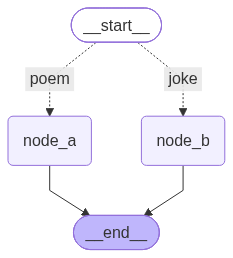

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_a(node_a)
	node_b(node_b)
	__end__([<p>__end__</p>]):::last
	__start__ -. &nbsp;poem&nbsp; .-> node_a;
	__start__ -. &nbsp;joke&nbsp; .-> node_b;
	node_a --> __end__;
	node_b --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [1]:
from typing import TypedDict,Literal
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from rich import print as rprint
from dotenv import load_dotenv
import os

load_dotenv(override=True)

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
GEMINI_BASE_URL=os.getenv("GEMINI_BASE_URL")

model = init_chat_model(
  model="gemini-2.5-flash",
  model_provider="google_genai",
  api_key=GEMINI_API_KEY,
  transport="rest"  # 强制使用 REST 协议
)

#1. 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str

#2. 定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"写一首关于{state['topic']}主题的诗"]).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"写一个关于{state['topic']}主题的笑话"]).content
    return {
        "joke": joke
    }

def my_route(state: OverAllState) -> Literal["poem","joke"]:
    if "诗" in state["content_type"]:
        return "poem"
    else:
        return "joke"


#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_conditional_edges(START,my_route,path_map={
    "poem":"node_a",
    "joke":"node_b"
})
builder.add_edge("node_b",END)
builder.add_edge("node_a",END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "猫咪","content_type":"诗"})
rprint(poem_res)

joke_res = graph.invoke({"topic": "猫咪","content_type":"笑话"})
rprint(joke_res)

from IPython.display import display
display(graph)
raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)